# Unlearning Insecurity: Active Inference, Bayesian Precision Weighting, and Cognitive Restructuring

### Computational Psychiatry, Dynamical Systems, and the Chaos Hearing Framework

How does an agent "unlearn" an insecurity without pharmaceuticals? In clinical psychiatry and cognitive science, the most robust empirical evidence for overcoming chronic self-doubt, shame, and social anxiety lies in **non-pharmacological paradigms**: 
- **Cognitive Behavioral Therapy (CBT)**: Cognitive restructuring (thought records) and behavioral experiments.
- **Exposure Therapy**: Gradual, deliberate habituation to feared contexts without avoidance.
- **Compassion-Focused Therapy (CFT)**: Activating a neurological "soothing/warmth" mode to silence harsh internal threat monitoring.
- **Acceptance and Commitment Therapy (ACT)**: Metacognitive defusion—treating thoughts as passing events rather than literal truths.

In this notebook, we formalize these psychiatric mechanisms within the **Chaos Hearing** framework using **Bayesian predictive coding**, **active inference**, and **nonlinear potential landscape morphing**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import Audio, display

# Aesthetic plot styling
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'lines.linewidth': 2.0,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--'
})

np.random.seed(42)
print("Environment initialized: Active Inference & Bayesian Inference suite ready.")

Environment initialized: Active Inference & Bayesian Inference suite ready.


## 1. The Anatomy of an Insecurity: Precision Weighting Under Causal Uncertainty ($H_{cu}$)

In predictive coding, perception is computed as a precision-weighted combination of sensory observations (likelihood) and internal generative priors:

$$\mu_{\text{post}} = \frac{\pi_{\text{lik}}\mu_{\text{lik}} + \pi_{\text{prior}}\mu_{\text{prior}}}{\pi_{\text{lik}} + \pi_{\text{prior}}}$$

where precision $\pi = 1 / \sigma^2$ is the inverse variance.

An **insecurity** is an over-weighted, hyper-precise negative prior ($\mu_{\text{prior}} \ll 0, \pi_{\text{prior}} \to \infty$). When ambiguous social or acoustic signals are received (high causal uncertainty $H_{cu}$, where $\pi_{\text{lik}} \approx 0$), the posterior estimate collapses completely onto the negative prior. The agent "hallucinates" rejection, contempt, or failure from pure ambient noise.

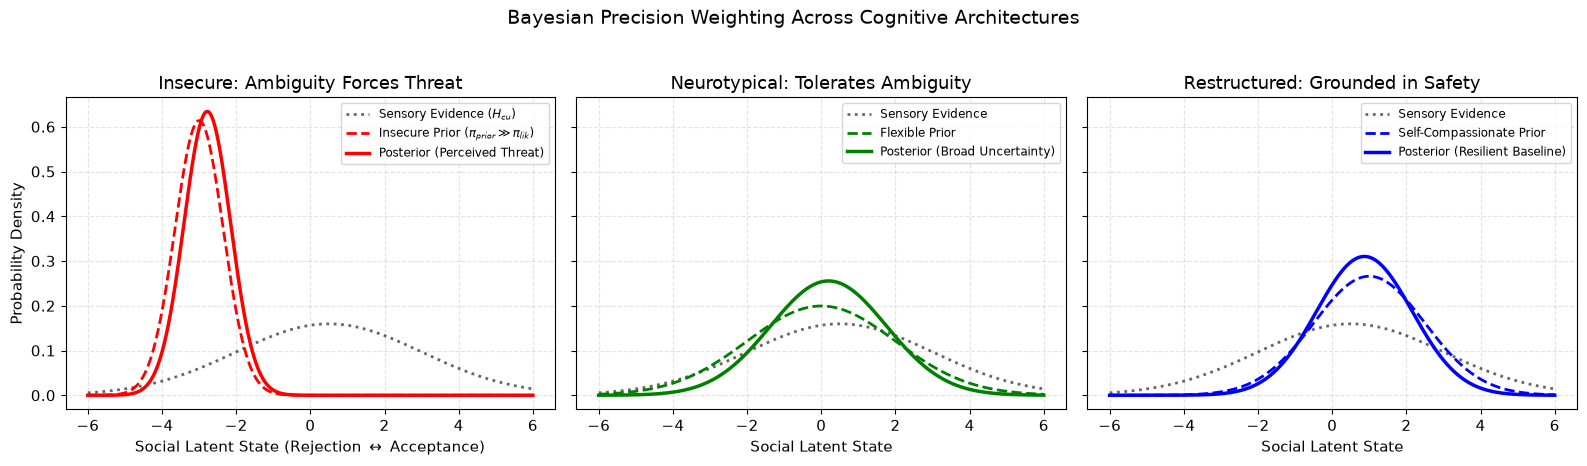

In [2]:
def compute_posterior(mu_lik, std_lik, mu_prior, std_prior):
    pi_lik = 1.0 / (std_lik ** 2)
    pi_prior = 1.0 / (std_prior ** 2)
    pi_post = pi_lik + pi_prior
    mu_post = (pi_lik * mu_lik + pi_prior * mu_prior) / pi_post
    std_post = np.sqrt(1.0 / pi_post)
    return mu_post, std_post

x = np.linspace(-6, 6, 1000)

# Ambiguous social stimulus: a neutral comment or glance (high H_cu, large variance)
mu_stimulus = 0.5
std_stimulus = 2.5
sensory_evidence = norm.pdf(x, mu_stimulus, std_stimulus)

# Profile 1: Insecure Cognitive Architecture (Hyper-precise negative prior)
mu_insecure = -3.0
std_insecure = 0.65
prior_insec = norm.pdf(x, mu_insecure, std_insecure)
mu_post_insec, std_post_insec = compute_posterior(mu_stimulus, std_stimulus, mu_insecure, std_insecure)
post_insec = norm.pdf(x, mu_post_insec, std_post_insec)

# Profile 2: Neurotypical Baseline (Flexible, moderate prior)
mu_neuro = 0.0
std_neuro = 2.0
prior_neuro = norm.pdf(x, mu_neuro, std_neuro)
mu_post_neuro, std_post_neuro = compute_posterior(mu_stimulus, std_stimulus, mu_neuro, std_neuro)
post_neuro = norm.pdf(x, mu_post_neuro, std_post_neuro)

# Profile 3: Restructured / Self-Compassionate (Grounded prior, resilient to ambiguity)
mu_cft = 1.0
std_cft = 1.5
prior_cft = norm.pdf(x, mu_cft, std_cft)
mu_post_cft, std_post_cft = compute_posterior(mu_stimulus, std_stimulus, mu_cft, std_cft)
post_cft = norm.pdf(x, mu_post_cft, std_post_cft)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

# Insecure
axes[0].plot(x, sensory_evidence, 'k:', label='Sensory Evidence ($H_{cu}$)', alpha=0.6)
axes[0].plot(x, prior_insec, 'r--', label='Insecure Prior ($\\pi_{prior} \\gg \\pi_{lik}$)')
axes[0].plot(x, post_insec, 'r-', lw=2.5, label='Posterior (Perceived Threat)')
axes[0].set_title('Insecure: Ambiguity Forces Threat')
axes[0].set_xlabel('Social Latent State (Rejection $\\leftrightarrow$ Acceptance)')
axes[0].set_ylabel('Probability Density')
axes[0].legend(loc='upper right', fontsize=8.5)

# Neurotypical
axes[1].plot(x, sensory_evidence, 'k:', label='Sensory Evidence', alpha=0.6)
axes[1].plot(x, prior_neuro, 'g--', label='Flexible Prior')
axes[1].plot(x, post_neuro, 'g-', lw=2.5, label='Posterior (Broad Uncertainty)')
axes[1].set_title('Neurotypical: Tolerates Ambiguity')
axes[1].set_xlabel('Social Latent State')
axes[1].legend(loc='upper right', fontsize=8.5)

# Restructured / CFT
axes[2].plot(x, sensory_evidence, 'k:', label='Sensory Evidence', alpha=0.6)
axes[2].plot(x, prior_cft, 'b--', label='Self-Compassionate Prior')
axes[2].plot(x, post_cft, 'b-', lw=2.5, label='Posterior (Resilient Baseline)')
axes[2].set_title('Restructured: Grounded in Safety')
axes[2].set_xlabel('Social Latent State')
axes[2].legend(loc='upper right', fontsize=8.5)

plt.suptitle('Bayesian Precision Weighting Across Cognitive Architectures', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## 2. Active Inference: The Avoidance Trap vs. Behavioral Experiments

Why can't you unlearn an insecurity just by "positive thinking"? 

Under **Active Inference**, agents select actions $a$ to minimize expected free energy $G$:
$$G(\pi) \approx \text{Epistemic Value (Information Gain)} - \text{Extrinsic Value (Goal Achievement)}$$

1. **Epistemic Avoidance (The Insecurity Trap)**:
   The insecure agent predicts that entering a vulnerable situation carries extreme risk. To avoid surprise, the agent adopts **safety behaviors** (staying quiet, hiding flaws, social withdrawal). 
   Crucially, avoidance yields **zero disconfirming observations**. With no new sensory data ($y_t$), the Kalman gain is zero:
   $$K_t = \frac{\sigma_{\text{prior}}^2}{\sigma_{\text{prior}}^2 + \sigma_{\text{lik}}^2} = 0$$
   The insecurity is never updated and remains permanently locked.

2. **CBT & Behavioral Experiments (Active Sampling)**:
   In exposure therapy and behavioral experiments, the agent deliberately takes actions that gather evidence (e.g., asking a question in public, disclosing a flaw). When the feared catastrophe does not occur, the benign environmental evidence $y_t \sim \mathcal{N}(\mu_{\text{safe}}, \sigma_w^2)$ generates a massive **sensory prediction error**:
   $$\delta_t = y_t - \mu_t$$
   This prediction error drives Bayesian updating of the prior mean and precision:
   $$\mu_{t+1} = \mu_t + K_t \delta_t$$
   $$\sigma_{t+1}^2 = (1 - K_t)\sigma_t^2 + \sigma_{\text{process}}^2$$

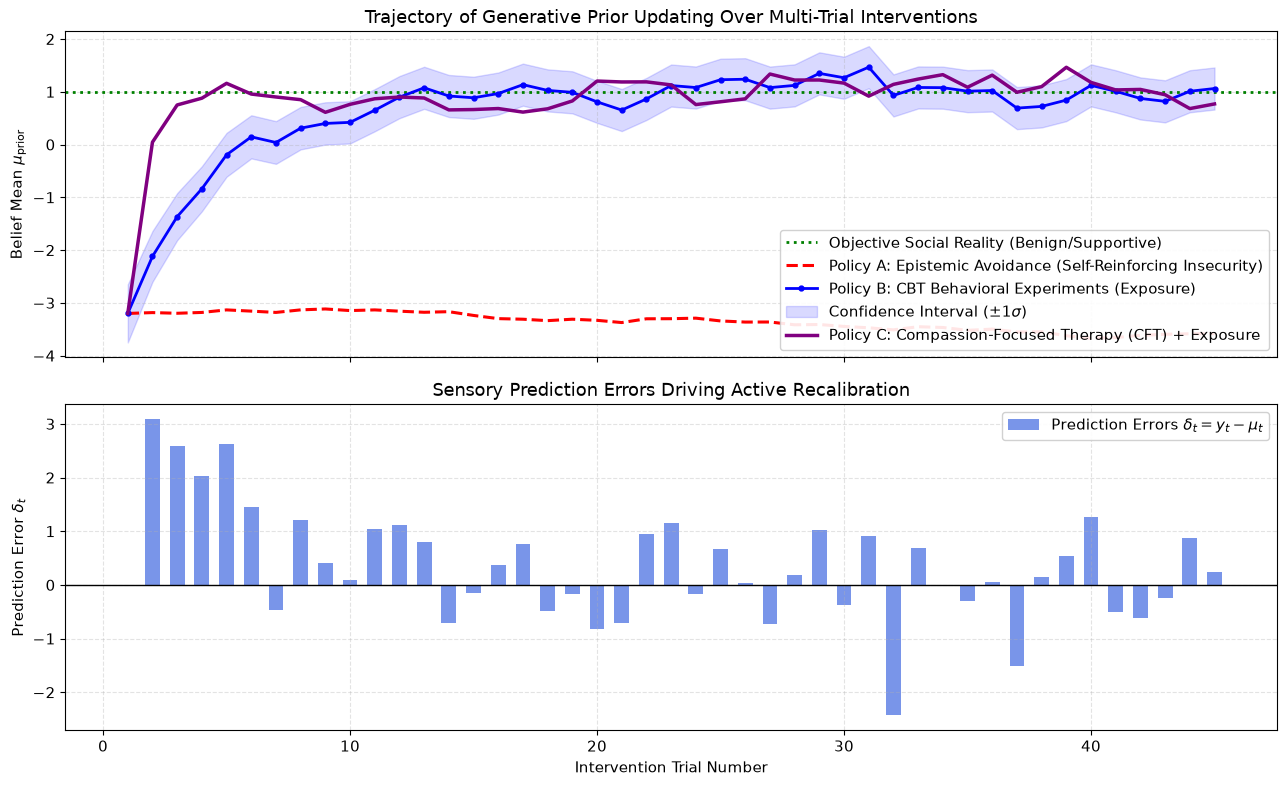

In [3]:
n_trials = 45
trials = np.arange(1, n_trials + 1)
true_safe_reality = 1.0
obs_noise_std = 0.75

# --- Policy A: Epistemic Avoidance (Withdrawal & Rumination) ---
mu_avoid = np.zeros(n_trials)
mu_avoid[0] = -3.2
for t in range(1, n_trials):
    # In rumination, without empirical observations, negative priors drift into deeper self-criticism
    mu_avoid[t] = mu_avoid[t-1] - 0.015 * np.sin(t / 4.0) + np.random.normal(0, 0.04)

# --- Policy B: Behavioral Experiments (Exposure Therapy / CBT) ---
mu_cbt = np.zeros(n_trials)
sigma_cbt = np.zeros(n_trials)
pe_cbt = np.zeros(n_trials)
mu_cbt[0] = -3.2
var_prior = 0.55**2
sigma_cbt[0] = np.sqrt(var_prior)

for t in range(1, n_trials):
    # Deliberate exposure trial: sample empirical reality
    y_t = np.random.normal(true_safe_reality, obs_noise_std)
    var_lik = obs_noise_std**2
    K_t = var_prior / (var_prior + var_lik)
    pe = y_t - mu_cbt[t-1]
    pe_cbt[t] = pe
    mu_cbt[t] = mu_cbt[t-1] + K_t * pe
    var_prior = (1.0 - K_t) * var_prior + 0.035  # dynamic learning rate
    sigma_cbt[t] = np.sqrt(var_prior)

# --- Policy C: Compassion-Focused Therapy (CFT) + Exposure ---
mu_cft_exp = np.zeros(n_trials)
mu_cft_exp[0] = -3.2
var_prior_cft = 1.1**2  # CFT relaxes rigid prior precision from the start
for t in range(1, n_trials):
    y_t = np.random.normal(true_safe_reality, obs_noise_std)
    var_lik = obs_noise_std**2
    K_t = var_prior_cft / (var_prior_cft + var_lik)
    pe = y_t - mu_cft_exp[t-1]
    # Self-soothing gain dampens threat volatility
    mu_cft_exp[t] = mu_cft_exp[t-1] + 1.25 * K_t * pe
    var_prior_cft = (1.0 - K_t) * var_prior_cft + 0.025

# Visualizing the Unlearning Dynamics
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Belief trajectories
ax1.axhline(true_safe_reality, color='green', linestyle=':', lw=2, label='Objective Social Reality (Benign/Supportive)')
ax1.plot(trials, mu_avoid, 'r--', lw=2.2, label='Policy A: Epistemic Avoidance (Self-Reinforcing Insecurity)')
ax1.plot(trials, mu_cbt, 'b-o', markersize=3.5, label='Policy B: CBT Behavioral Experiments (Exposure)')
ax1.fill_between(trials, mu_cbt - sigma_cbt, mu_cbt + sigma_cbt, color='blue', alpha=0.15, label='Confidence Interval ($\\pm 1\\sigma$)')
ax1.plot(trials, mu_cft_exp, 'purple', lw=2.5, label='Policy C: Compassion-Focused Therapy (CFT) + Exposure')
ax1.set_ylabel('Belief Mean $\\mu_{\\text{prior}}$')
ax1.set_title('Trajectory of Generative Prior Updating Over Multi-Trial Interventions')
ax1.legend(loc='lower right', framealpha=0.9)

# Prediction errors
ax2.bar(trials, pe_cbt, color='royalblue', alpha=0.7, width=0.6, label='Prediction Errors $\\delta_t = y_t - \\mu_t$')
ax2.axhline(0, color='k', lw=1)
ax2.set_xlabel('Intervention Trial Number')
ax2.set_ylabel('Prediction Error $\\delta_t$')
ax2.set_title('Sensory Prediction Errors Driving Active Recalibration')
ax2.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

## 3. Dynamical Systems: Free Energy Potential Landscape Deformation

In dynamical systems and the Free Energy Principle, internal cognitive states evolve along an effective potential energy landscape $U(x) = -\ln p(x)$. 

- **The Insecurity Attractor**: A deep potential well at $x_{\text{insecure}}$, surrounded by a high energetic barrier that traps the system. Stochastic boundary crossings from social noise (P-bifurcations) repeatedly knock the state into panic.
- **CBT & ACT Metacognitive Defusion**: Lowers the barrier between self-doubt and security by decoupling thoughts from reality.
- **Post-Exposure Integration**: The global minimum shifts from the negative attractor into an adaptive, resilient baseline.

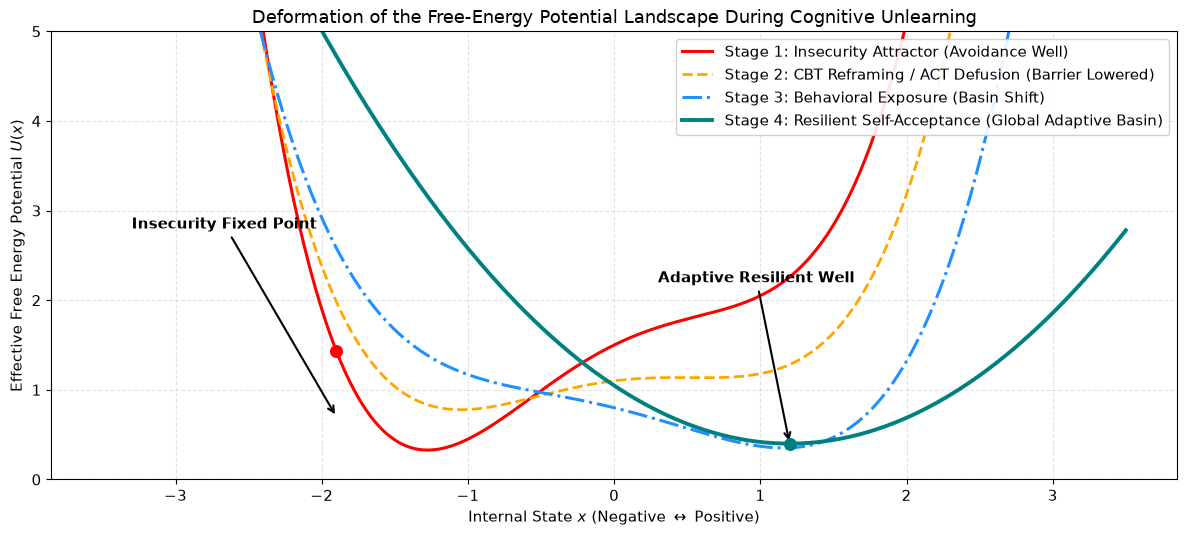

In [4]:
v_x = np.linspace(-3.5, 3.5, 600)

# Phase 1: Entrenched Insecurity (Avoidance Lock-in)
U_1 = 0.25 * (v_x**4) - 0.5 * (v_x**2) + 0.8 * v_x + 1.5

# Phase 2: Cognitive Restructuring & Metacognitive Defusion (ACT / CBT)
U_2 = 0.18 * (v_x**4) - 0.3 * (v_x**2) + 0.2 * v_x + 1.1

# Phase 3: Active Exposure (Barrier Inversion)
U_3 = 0.12 * (v_x**4) - 0.15 * (v_x**2) - 0.4 * v_x + 0.8

# Phase 4: Self-Compassionate Resilient Basin
U_4 = 0.45 * (v_x - 1.2)**2 + 0.4

plt.figure(figsize=(12, 5.5))
plt.plot(v_x, U_1, 'r-', lw=2.2, label='Stage 1: Insecurity Attractor (Avoidance Well)')
plt.plot(v_x, U_2, 'orange', linestyle='--', lw=2.0, label='Stage 2: CBT Reframing / ACT Defusion (Barrier Lowered)')
plt.plot(v_x, U_3, 'dodgerblue', linestyle='-.', lw=2.2, label='Stage 3: Behavioral Exposure (Basin Shift)')
plt.plot(v_x, U_4, 'teal', lw=2.8, label='Stage 4: Resilient Self-Acceptance (Global Adaptive Basin)')

# Annotations
plt.scatter([-1.9], [0.25 * ((-1.9)**4) - 0.5 * ((-1.9)**2) + 0.8 * (-1.9) + 1.5], color='red', s=70, zorder=5)
plt.annotate('Insecurity Fixed Point', xy=(-1.9, 0.7), xytext=(-3.3, 2.8),
             arrowprops=dict(facecolor='red', arrowstyle='->', lw=1.5), fontweight='bold')

plt.scatter([1.2], [0.4], color='teal', s=70, zorder=5)
plt.annotate('Adaptive Resilient Well', xy=(1.2, 0.4), xytext=(0.3, 2.2),
             arrowprops=dict(facecolor='teal', arrowstyle='->', lw=1.5), fontweight='bold')

plt.title('Deformation of the Free-Energy Potential Landscape During Cognitive Unlearning', fontsize=13)
plt.xlabel('Internal State $x$ (Negative $\\leftrightarrow$ Positive)')
plt.ylabel('Effective Free Energy Potential $U(x)$')
plt.ylim([0, 5.0])
plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

## 4. Acoustic Metaphor & Sonification: From Harsh Resonance to Harmonic Equilibrium

In **Chaos Hearing**, we synthesize auditory correlates of cognitive states:
- **The Insecurity State (The Harsh Inner Critic)**: An audio circuit with a hyper-resonant, narrow-band feedback filter ($Q \gg 10$), ringing relentlessly at an irritating, dissonant frequency, clipping against sensory limits.
- **The Unlearned State (Self-Compassionate Stabilization)**: Relaxed $Q$-factor, warm harmonic overtone dispersion, soft non-linear damping, and broad spectral entropy.

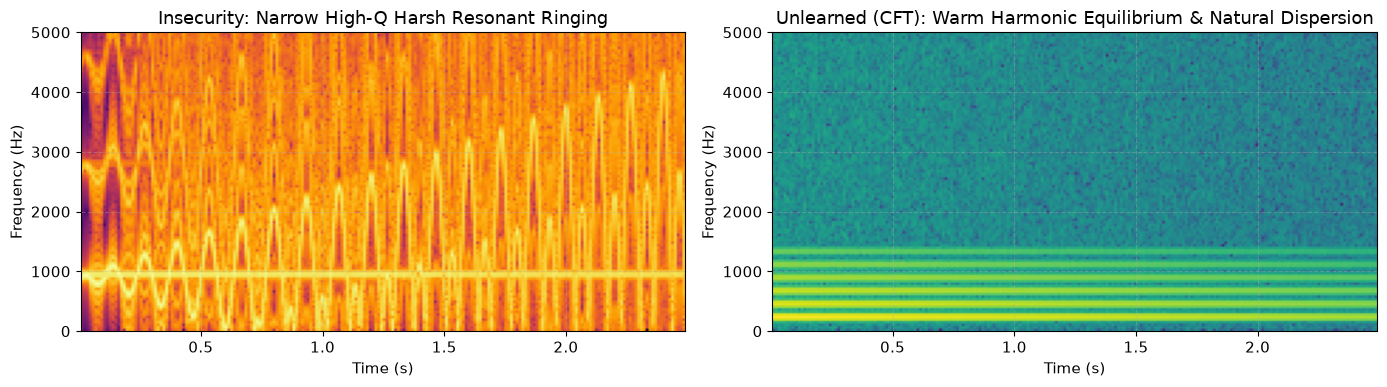

1. Audio Demo: The Critical Voice (Insecurity / Harsh High-Q Resonance):


2. Audio Demo: The Unlearned State (Self-Compassion / Warm Harmonic Equilibrium):


In [5]:
sr = 22050
duration = 2.5
t_audio = np.linspace(0, duration, int(sr * duration), endpoint=False)

# --- 1. Synthesize Insecure Critical Inner Voice (High Q, Discordant Ringing, Harsh Clipping) ---
f_insecure = 880.0  # piercing high frequency
mod = np.sin(2 * np.pi * 7.5 * t_audio)  # rapid anxious tremor
raw_insecure = np.sin(2 * np.pi * (f_insecure + 30 * mod) * t_audio)
# Add harmonic dissonance (minor second clash at 932 Hz)
raw_insecure += 0.7 * np.sin(2 * np.pi * 932.3 * t_audio)
# Apply harsh non-linear clipping (cognitive rigidity)
insecure_audio = np.tanh(2.5 * raw_insecure) * np.exp(-0.2 * t_audio)
insecure_audio = insecure_audio / np.max(np.abs(insecure_audio))

# --- 2. Synthesize Unlearned / Self-Compassionate Sound (Warm Harmonic Dispersion, Low Q) ---
f_base = 220.0  # warm A3 fundamental
cft_audio = np.zeros_like(t_audio)
# Generative harmonic series with 1/f spectral decay (natural, comforting acoustic profile)
for k, amp in enumerate([1.0, 0.6, 0.4, 0.25, 0.15, 0.08], start=1):
    cft_audio += amp * np.sin(2 * np.pi * (f_base * k) * t_audio) * np.exp(-0.6 * t_audio)
# Add subtle pink noise dispersion (representing open causal uncertainty without distress)
ambient_noise = np.random.normal(0, 0.04, len(t_audio)) * np.exp(-0.4 * t_audio)
cft_audio = (cft_audio + ambient_noise)
cft_audio = cft_audio / np.max(np.abs(cft_audio))

# Display spectrograms
fig, (ax_insec, ax_cft) = plt.subplots(1, 2, figsize=(14, 4))
ax_insec.specgram(insecure_audio, Fs=sr, NFFT=512, noverlap=256, cmap='inferno')
ax_insec.set_title('Insecurity: Narrow High-Q Harsh Resonant Ringing')
ax_insec.set_xlabel('Time (s)')
ax_insec.set_ylabel('Frequency (Hz)')
ax_insec.set_ylim([0, 5000])

ax_cft.specgram(cft_audio, Fs=sr, NFFT=512, noverlap=256, cmap='viridis')
ax_cft.set_title('Unlearned (CFT): Warm Harmonic Equilibrium & Natural Dispersion')
ax_cft.set_xlabel('Time (s)')
ax_cft.set_ylabel('Frequency (Hz)')
ax_cft.set_ylim([0, 5000])
plt.tight_layout()
plt.show()

print("1. Audio Demo: The Critical Voice (Insecurity / Harsh High-Q Resonance):")
display(Audio(insecure_audio, rate=sr))

print("2. Audio Demo: The Unlearned State (Self-Compassion / Warm Harmonic Equilibrium):")
display(Audio(cft_audio, rate=sr))

## 5. Summary: Computational Psychiatry Synthesis

| Clinical Modality | Core Mechanism | Active Inference / Chaos Hearing Implementation |
| :--- | :--- | :--- |
| **CBT (Thought Records)** | Question automatic thoughts with factual evidence | **Prior Precision Attenuation ($\pi_{\text{prior}} \downarrow$)**: Prevents prior from overpowering ambiguous evidence. |
| **Behavioral Experiments** | Deliberately testing predictions in real-world actions | **Active Epistemic Sampling**: Generates sensory prediction errors $\delta_t = y_t - \mu_t$ that update prior mean. |
| **Exposure Therapy** | Habituation without avoidance | **Eliminating Epistemic Avoidance**: Overcomes zero-Kalman-gain stagnation. |
| **Compassion-Focused Therapy** | Activating soothing neurological mode | **Threat-Gain Modulation & Noise Stabilization**: Prevents stochastic noise from triggering panic bifurcations. |
| **ACT (Acceptance)** | Defusing thoughts from objective reality | **Metacognitive Decoupling**: Tolerating high causal uncertainty ($H_{cu}$) without reactive motor avoidance. |

**Key Takeaway**: Unlearning an insecurity is an active Bayesian recalibration process. Avoidance preserves maladaptive hyper-precise priors indefinitely. Systematic exposure and self-compassion generate the prediction errors and autonomic regulation necessary to flatten the fear attractor and establish a resilient, grounded equilibrium.